# CS2AI – WDBC Dataset: EDA and Preprocessing
**Section 6–7 · Member A**

Dataset: Wisconsin Diagnostic Breast Cancer (WDBC), UCI ML Repository  
Task: Binary classification — Malignant (M) vs Benign (B)

In [21]:
# ── Cell 1: Imports and paths ──────────────────────────────────────────────
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

DATA_PATH = "../Dataset/wdbc.data"

FIG_DIR = "../Figures&Tables"
OUTPUT_DIR = "../Dataset"  

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20

def save_fig(name):
    """Save to FIG_DIR and also display inline."""
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')
    plt.show()

In [22]:
# ── Cell 2: Load data ──────────────────────────────────────────────────────
# WDBC features are arranged as: 10 means → 10 SEs → 10 worsts
# (wdbc.names: field 3=mean radius, field 13=radius SE, field 23=worst radius)
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
]
feature_names = (
    [f'{f}_mean'  for f in base_features] +
    [f'{f}_se'    for f in base_features] +
    [f'{f}_worst' for f in base_features]
)

df = pd.read_csv(DATA_PATH, header=None, names=['ID', 'diagnosis'] + feature_names)
df = df.drop('ID', axis=1)  # non-predictive

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()
print(df['diagnosis'].value_counts().rename('count').to_frame()
        .assign(pct=lambda d: (d['count'] / len(df) * 100).round(1)))

Shape          : (569, 31)
Missing values : 0
Duplicates     : 0

           count   pct
diagnosis             
B            357  62.7
M            212  37.3


In [23]:
# ── Cell 3: Quick feature statistics ──────────────────────────────────────
X = df.drop('diagnosis', axis=1)
y = (df['diagnosis'] == 'M').astype(int)  # M=1, B=0

X.describe().round(3)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


C:\Users\32998\AppData\Local\Temp\ipykernel_28236\3810001394.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\32998\AppData\Local\Temp\ipykernel_28236\3810001394.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\32998\AppData\Local\Temp\ipykernel_28236\3810001394.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\32998\AppData\Local\Temp\ipykernel_28236\3810001394.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will 

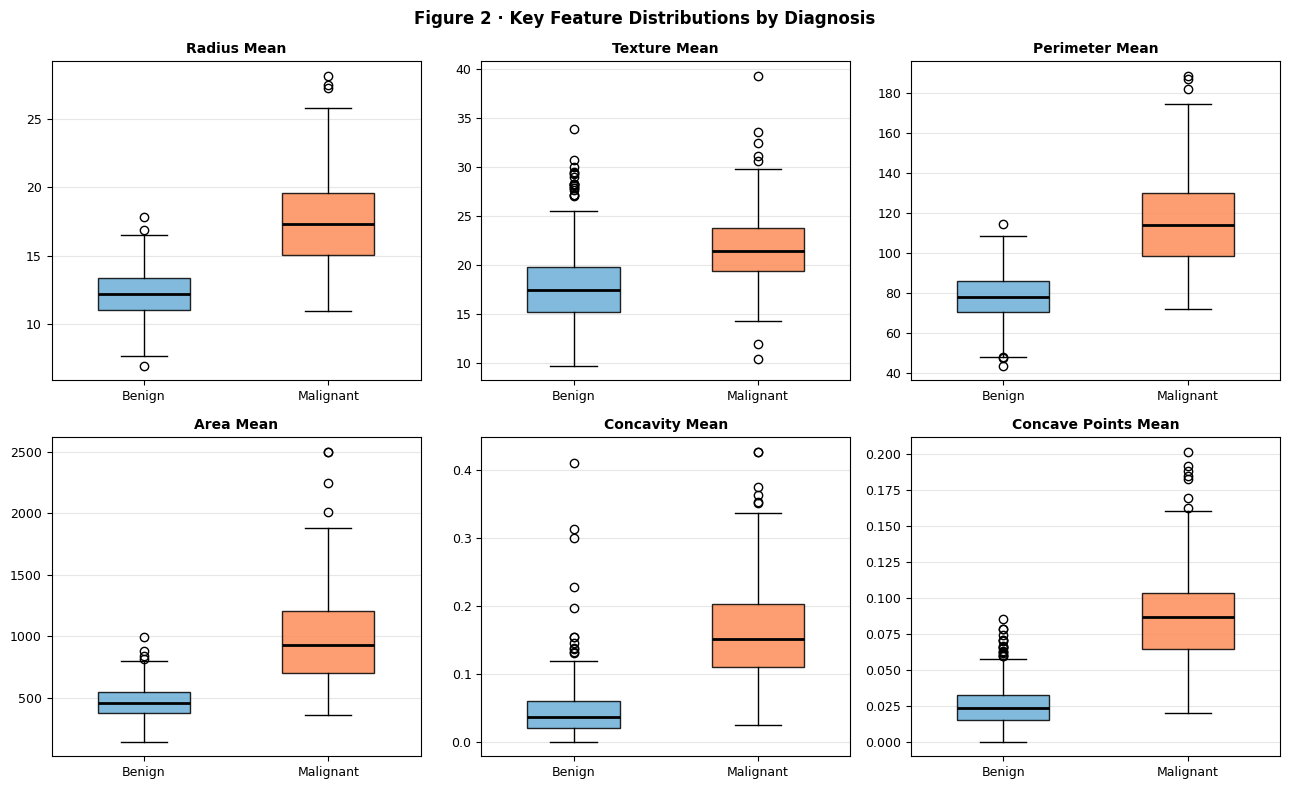

In [24]:
# ── Cell 4: Figure 2 – Key feature distributions by diagnosis (2×3) ───────
key_features = [
    'radius_mean', 'texture_mean', 'perimeter_mean',
    'area_mean', 'concavity_mean', 'concave_points_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    b_vals = X.loc[y == 0, feat]
    m_vals = X.loc[y == 1, feat]

    bp = axes[i].boxplot(
        [b_vals, m_vals],
        labels=['Benign', 'Malignant'],   # ← 修改这里
        patch_artist=True,
        widths=0.5,
        medianprops=dict(
            color='black',
            linewidth=2
        )
    )

    # box colors
    bp['boxes'][0].set_facecolor('#6baed6')
    bp['boxes'][0].set_alpha(0.85)

    bp['boxes'][1].set_facecolor('#fc8d59')
    bp['boxes'][1].set_alpha(0.85)

    # title & style
    axes[i].set_title(
        feat.replace('_', ' ').title(),
        fontsize=10,
        fontweight='bold'
    )

    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(labelsize=9)

fig.suptitle(
    'Figure 2 · Key Feature Distributions by Diagnosis',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
save_fig('fig2_feature_boxplots.png')
plt.show()

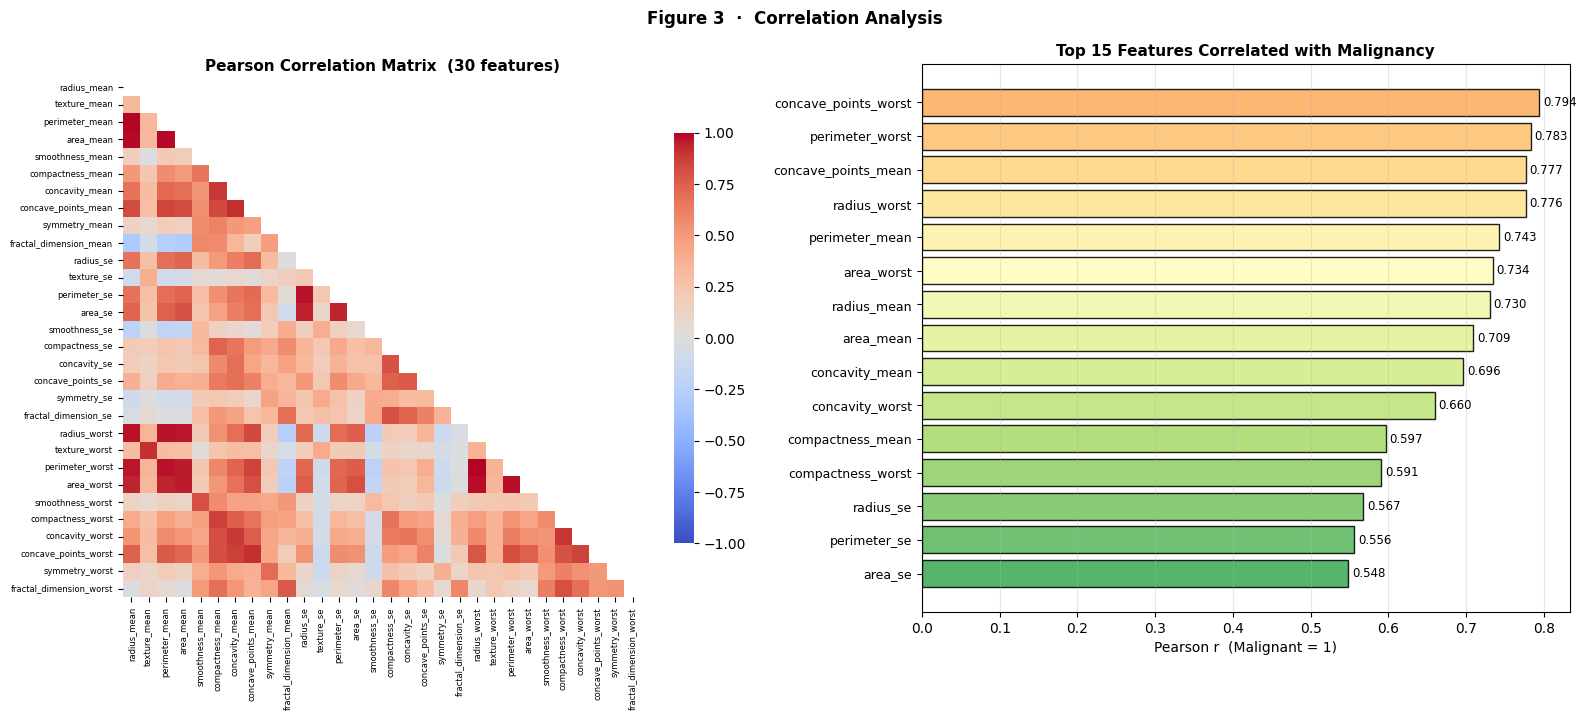

Top 5 features by |r| with diagnosis:
concave_points_worst    0.794
perimeter_worst         0.783
concave_points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
Name: diagnosis, dtype: float64


In [25]:
# ── Cell 5: Figure 3 – Correlation heatmap + Top-15 bar (1×2) ─────────────
X_c = X.copy()
X_c['diagnosis'] = y
corr   = X_c.corr()
t_corr = corr['diagnosis'].drop('diagnosis').sort_values(ascending=False)
top15  = t_corr.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: heatmap (features only, lower triangle)
feat_corr = corr.loc[feature_names, feature_names]
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, cmap='coolwarm', center=0,
    ax=axes[0], square=True, cbar_kws={'shrink': 0.75},
    linewidths=0, vmin=-1, vmax=1
)
axes[0].set_title('Pearson Correlation Matrix  (30 features)', fontsize=11, fontweight='bold')
axes[0].tick_params(labelsize=6)

# Right: Top-15 by |r| with diagnosis
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, 15))
axes[1].barh(range(15), top15.values, color=bar_colors, edgecolor='black', alpha=0.88)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Pearson r  (Malignant = 1)', fontsize=10)
axes[1].set_title('Top 15 Features Correlated with Malignancy', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top15.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8.5)

fig.suptitle('Figure 3  ·  Correlation Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('fig3_correlation.png')

print("Top 5 features by |r| with diagnosis:")
print(top15.head().round(3))

In [26]:
# ── Cell 6: Stratified train/test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train  B:{(y_train==0).sum()}  M:{(y_train==1).sum()}  "
      f"({(y_train==0).mean()*100:.1f}% / {(y_train==1).mean()*100:.1f}%)")
print(f"Test   B:{(y_test==0).sum()}   M:{(y_test==1).sum()}  "
      f"({(y_test==0).mean()*100:.1f}% / {(y_test==1).mean()*100:.1f}%)")

Train: (455, 30)  |  Test: (114, 30)
Train  B:285  M:170  (62.6% / 37.4%)
Test   B:72   M:42  (63.2% / 36.8%)


In [27]:
# ── Cell 7: Feature standardisation ───────────────────────────────────────
# Scaler is fit on training data only → test set transformed with training params.
# This prevents any information from the test set leaking into the model inputs.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train scaled  →  mean: {X_train_scaled.mean():.5f}   std: {X_train_scaled.std():.5f}")
print(f"Test  scaled  →  mean: {X_test_scaled.mean():.5f}   std: {X_test_scaled.std():.5f}")

Train scaled  →  mean: 0.00000   std: 1.00000
Test  scaled  →  mean: -0.02401   std: 0.93113


In [28]:
# ── Cell 8: SMOTE oversampling (training set only) ─────────────────────────
# Applied after scaling so interpolation is in standardised feature space.
# Test set is never touched — it keeps the original class distribution.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_smote).value_counts().sort_index()
print(f"Before SMOTE  →  B:{before[0]}  M:{before[1]}  (ratio {before[0]/before[1]:.2f}:1)")
print(f"After  SMOTE  →  B:{after[0]}  M:{after[1]}   (ratio {after[0]/after[1]:.2f}:1)")
print(f"Synthetic samples added: {after[1] - before[1]}")

print("\nFor Members B and C:")
print("  Training  →  X_train_smote.csv + y_train_smote.csv   (both models, fair comparison)")
print("  Testing   →  X_test_scaled.csv  + y_test.csv          (unified, never SMOTE'd)")
print("  Baseline  →  X_train_scaled.csv + y_train.csv         (no-SMOTE ablation)")

Before SMOTE  →  B:285  M:170  (ratio 1.68:1)
After  SMOTE  →  B:285  M:285   (ratio 1.00:1)
Synthetic samples added: 115

For Members B and C:
  Training  →  X_train_smote.csv + y_train_smote.csv   (both models, fair comparison)
  Testing   →  X_test_scaled.csv  + y_test.csv          (unified, never SMOTE'd)
  Baseline  →  X_train_scaled.csv + y_train.csv         (no-SMOTE ablation)


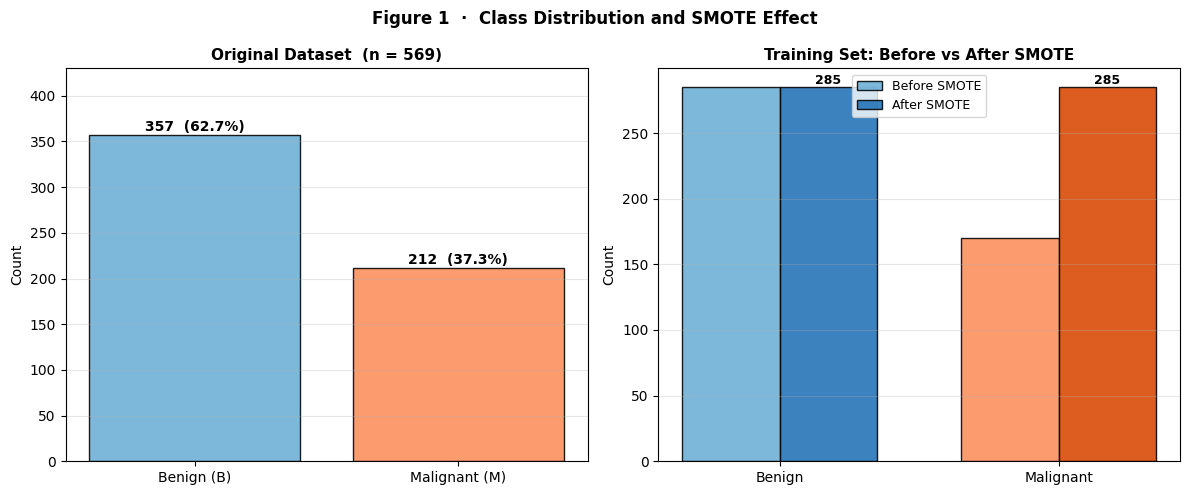

In [29]:
# ── Cell 9: Figure 1 – Class distribution + SMOTE comparison ──────────────
# Generated here because y_train_smote is required for the right panel.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original full dataset
counts = df['diagnosis'].value_counts()
c_b, c_m = counts['B'], counts['M']
axes[0].bar(['Benign (B)', 'Malignant (M)'], [c_b, c_m],
            color=['#6baed6', '#fc8d59'], edgecolor='black', alpha=0.88)
for i, v in enumerate([c_b, c_m]):
    axes[0].text(i, v + 4, f'{v}  ({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Original Dataset  (n = 569)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_ylim(0, 430)
axes[0].grid(axis='y', alpha=0.3)

# Right: training set before vs after SMOTE
x_pos = np.arange(2)
w = 0.35
b1 = axes[1].bar(x_pos - w/2, [before[0], before[1]], w,
                 label='Before SMOTE', color=['#6baed6','#fc8d59'],
                 alpha=0.88, edgecolor='black')
b2 = axes[1].bar(x_pos + w/2, [after[0],  after[1]],  w,
                 label='After SMOTE',  color=['#2171b5','#d94701'],
                 alpha=0.88, edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Benign', 'Malignant'], fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Training Set: Before vs After SMOTE', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
for bar in b2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 2,
                 str(int(h)), ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Figure 1  ·  Class Distribution and SMOTE Effect',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('fig1_class_smote.png')

In [30]:
# ── Cell 10: Save all output files ────────────────────────────────────────
def p(name):
    return os.path.join(OUTPUT_DIR, name)

# Training set – original (for ablation)
pd.DataFrame(X_train_scaled, columns=feature_names).to_csv(p('X_train_scaled.csv'), index=False)
pd.DataFrame({'diagnosis': y_train.values}).to_csv(p('y_train.csv'), index=False)

# Training set – SMOTE balanced (primary for B & C)
pd.DataFrame(X_train_smote, columns=feature_names).to_csv(p('X_train_smote.csv'), index=False)
pd.DataFrame({'diagnosis': y_train_smote}).to_csv(p('y_train_smote.csv'), index=False)

# Test set (unified, original distribution)
pd.DataFrame(X_test_scaled, columns=feature_names).to_csv(p('X_test_scaled.csv'), index=False)
pd.DataFrame({'diagnosis': y_test.values}).to_csv(p('y_test.csv'), index=False)

# Scaler and feature list for reproducibility
with open(p('scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(p('feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)

print(f"All files saved to: {OUTPUT_DIR}\n")
print("  X_train_scaled.csv  /  y_train.csv       →  455 × 30  (no-SMOTE baseline)")
print("  X_train_smote.csv   /  y_train_smote.csv →  570 × 30  (primary training)")
print("  X_test_scaled.csv   /  y_test.csv        →  114 × 30  (unified test set)")
print("  scaler.pkl  /  feature_names.pkl")

All files saved to: ../Dataset

  X_train_scaled.csv  /  y_train.csv       →  455 × 30  (no-SMOTE baseline)
  X_train_smote.csv   /  y_train_smote.csv →  570 × 30  (primary training)
  X_test_scaled.csv   /  y_test.csv        →  114 × 30  (unified test set)
  scaler.pkl  /  feature_names.pkl


In [31]:
import pandas as pd
import os

summary = pd.DataFrame({
    "Step": [
        "Load data",
        "Clean data",
        "Train/test split",
        "Feature scaling",
        "SMOTE",
        "Export files"
    ],
    "Description": [
        "Loaded WDBC dataset with 569 samples and 30 numerical features.",
        "Removed ID column and encoded diagnosis labels: B=0, M=1.",
        "Used stratified 80/20 split with random_state=42.",
        "Fitted StandardScaler on training data only, then transformed train and test sets.",
        "Applied SMOTE only to the scaled training set.",
        "Saved scaled train/test data and SMOTE-resampled training data as CSV files."
    ],
    "Output": [
        "Raw dataframe",
        "X, y",
        "X_train, X_test, y_train, y_test",
        "X_train_scaled, X_test_scaled",
        "X_train_smote, y_train_smote",
        "6 CSV files"
    ]
})

summary.to_csv(os.path.join(OUTPUT_DIR, "preprocessing_summary.csv"), index=False)
summary


,Step,Description,Output
0,Load data,Loaded WDBC dataset with 569 samples and 30 nu...,Raw dataframe
1,Clean data,Removed ID column and encoded diagnosis labels...,"X, y"
2,Train/test split,Used stratified 80/20 split with random_state=42.,"X_train, X_test, y_train, y_test"
3,Feature scaling,"Fitted StandardScaler on training data only, t...","X_train_scaled, X_test_scaled"
4,SMOTE,Applied SMOTE only to the scaled training set.,"X_train_smote, y_train_smote"
5,Export files,Saved scaled train/test data and SMOTE-resampl...,6 CSV files
